# WISDM Activity Recognition (v1.1) - Quick Load and Summary

This notebook loads the WISDM CSV dataset and prints a quick summary.

Columns: `user`, `activity`, `timestamp`, `x-axis`, `y-axis`, `z-axis`

Notes:
- Sampling rate is 20Hz (1 sample every 50ms).
- 1,073,623 rows of raw accelerometer readings across 6 activity classes.

In [1]:
from pathlib import Path
import pandas as pd
import seaborn as sns
from matplotlib import pyplot as plt

# Resolve repo root whether the notebook is launched from repo root or notebooks/
REPO_ROOT = Path.cwd()
if not (REPO_ROOT / "src").exists() and (REPO_ROOT.parent / "src").exists():
    REPO_ROOT = REPO_ROOT.parent

DATA_DIR = REPO_ROOT / "WISDM_ar_v1.1"
CSV_PATH = DATA_DIR / "WISDM_ar_v1.1_raw.csv"


In [2]:
df = pd.read_csv(CSV_PATH)

df.head(10)

,user,activity,timestamp,x-axis,y-axis,z-axis
0,1,Walking,4991922345000,0.69,10.80,-2.03
1,1,Walking,4991972333000,6.85,7.44,-0.50
2,1,Walking,4992022351000,0.93,5.63,-0.50
3,1,Walking,4992072339000,-2.11,5.01,-0.69
4,1,Walking,4992122358000,-4.59,4.29,-1.95
5,1,Walking,4992172376000,12.41,11.18,7.82
6,1,Walking,4992222333000,17.27,11.60,5.94
7,1,Walking,4992272321000,1.42,8.43,-5.28
8,1,Walking,4992322339000,-2.68,15.89,-0.38
9,1,Walking,4992372327000,-1.38,9.92,-1.99


In [3]:
df.tail(10)

,user,activity,timestamp,x-axis,y-axis,z-axis
1073613,36,Standing,15048762281000,-1.27,9.28,2.560625
1073614,36,Standing,15048812207000,-1.61,9.30,2.724070
1073615,36,Standing,15048862287000,-1.31,9.43,2.833032
1073616,36,Standing,15048912275000,-1.18,9.47,2.724070
1073617,36,Standing,15048962262000,-0.91,9.19,2.560625
1073618,36,Standing,15049012250000,-0.91,9.43,2.533385
1073619,36,Standing,15049062268000,-1.18,9.51,2.492524
1073620,36,Standing,15049112287000,-1.50,9.53,2.533385
1073621,36,Standing,15049162275000,-2.07,8.77,2.179256
1073622,36,Standing,15049212262000,-2.14,9.89,3.255263


In [4]:
print("rows:", len(df), "cols:", df.shape[1])
print("missing values:", int(df.isna().sum().sum()))
print("zero timestamps:", int((df["timestamp"] == 0).sum()))
print("class distribution (activity):")
display(df["activity"].value_counts())
display((df["activity"].value_counts(normalize=True) * 100).round(2))

print("unique users:", df["user"].nunique())
display(df["user"].value_counts().head(10))

df[["x-axis", "y-axis", "z-axis"]].describe()


rows: 1073623 cols: 6
missing values: 0
zero timestamps: 0
class distribution (activity):


activity
Walking       417901
Jogging       324600
Upstairs      122598
Downstairs    100192
Sitting        59939
Standing       48393
Name: count, dtype: int64

activity
Walking       38.92
Jogging       30.23
Upstairs      11.42
Downstairs     9.33
Sitting        5.58
Standing       4.51
Name: proportion, dtype: float64

unique users: 36


user
20    54294
19    45382
31    44282
8     41187
14    38192
29    36768
13    36063
34    35947
3     35158
10    34875
Name: count, dtype: int64

,x-axis,y-axis,z-axis
count,1.073623e+06,1.073623e+06,1.073623e+06
mean,6.720567e-01,7.332700e+00,4.024567e-01
std,6.916894e+00,6.732950e+00,4.789301e+00
min,-1.961000e+01,-1.961000e+01,-1.980000e+01
25%,-2.960000e+00,3.340000e+00,-2.260978e+00
50%,3.400000e-01,8.010000e+00,-4.000000e-02
75%,4.520000e+00,1.160000e+01,2.760000e+00
max,1.995000e+01,2.004000e+01,1.961000e+01


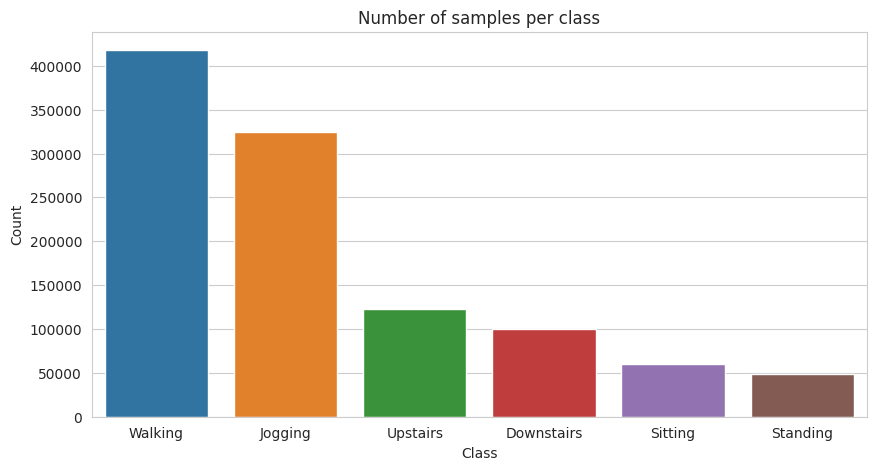

In [5]:
sns.set_style('whitegrid')
plt.figure(figsize=(10, 5))
sns.countplot(x='activity', data=df, palette='tab10', hue='activity', legend=False)
plt.xlabel('Class')
plt.ylabel('Count')
plt.title('Number of samples per class')
plt.show()

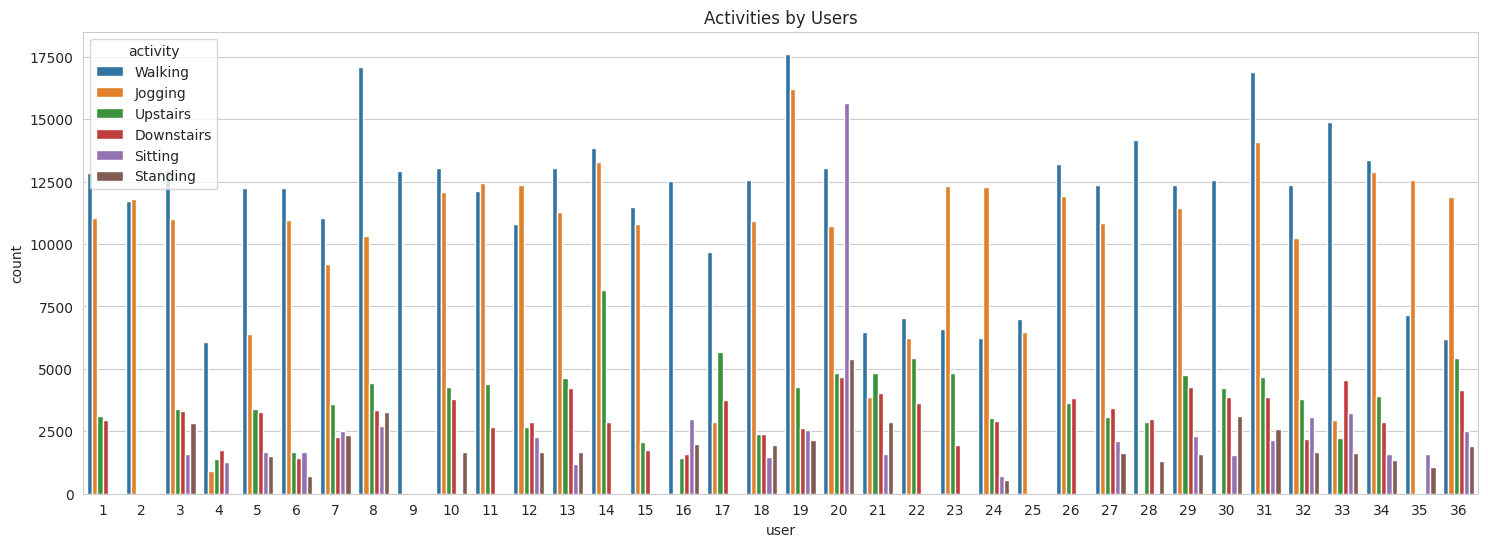

In [6]:
plt.figure(figsize = (18, 6))
sns.countplot(x = 'user', hue = 'activity', data = df)
plt.title('Activities by Users')
plt.show()

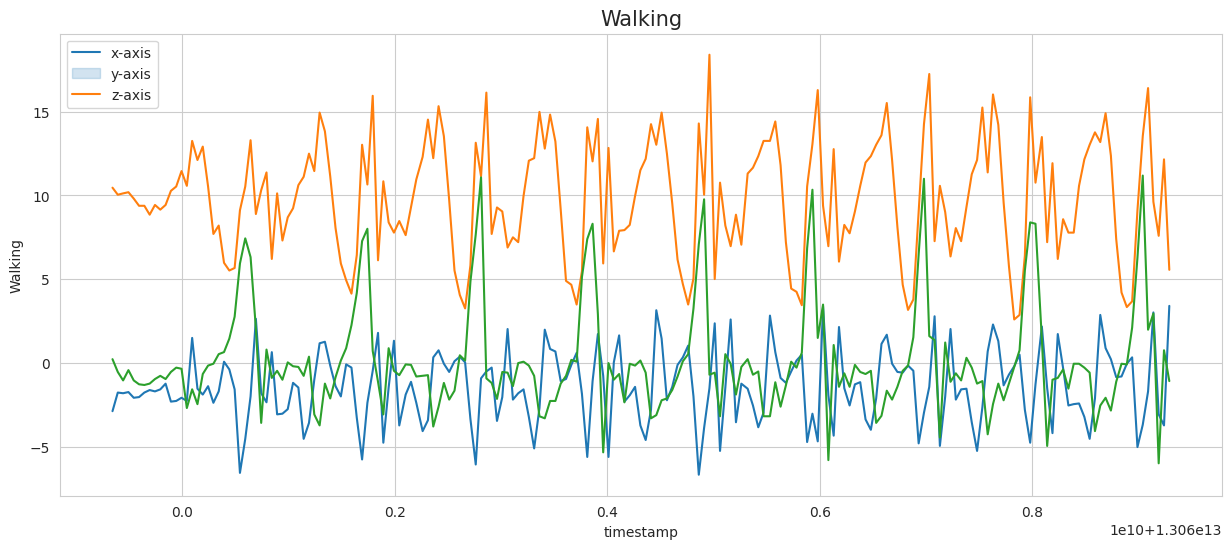

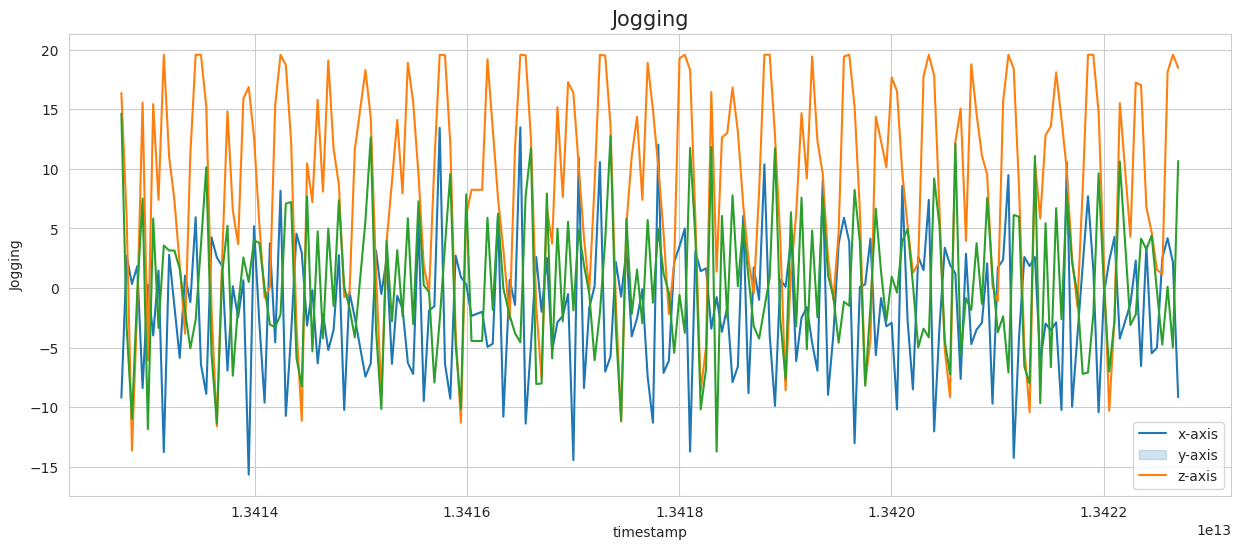

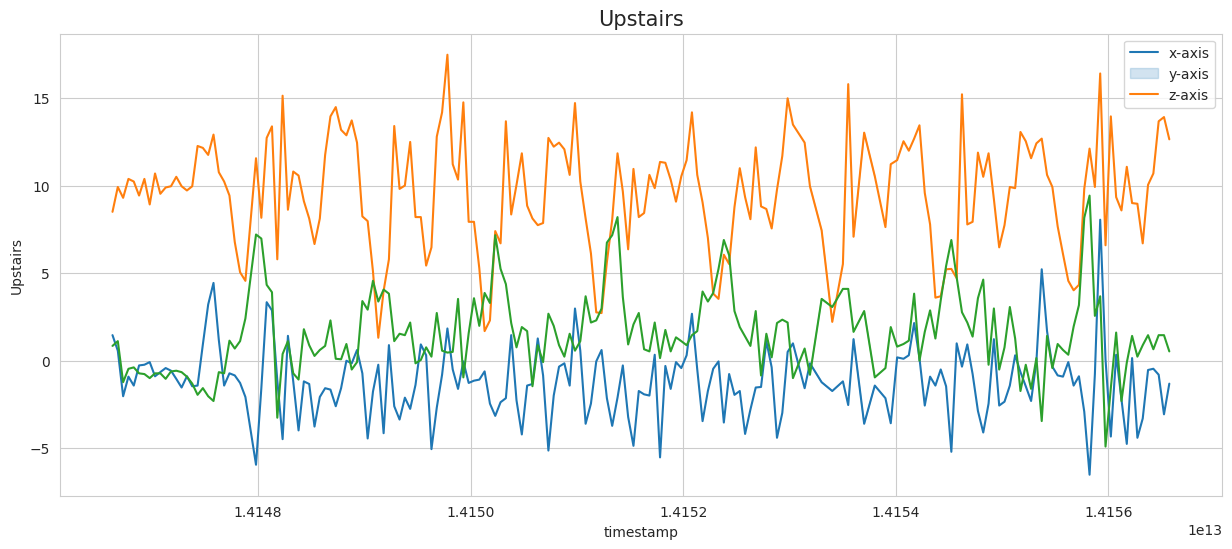

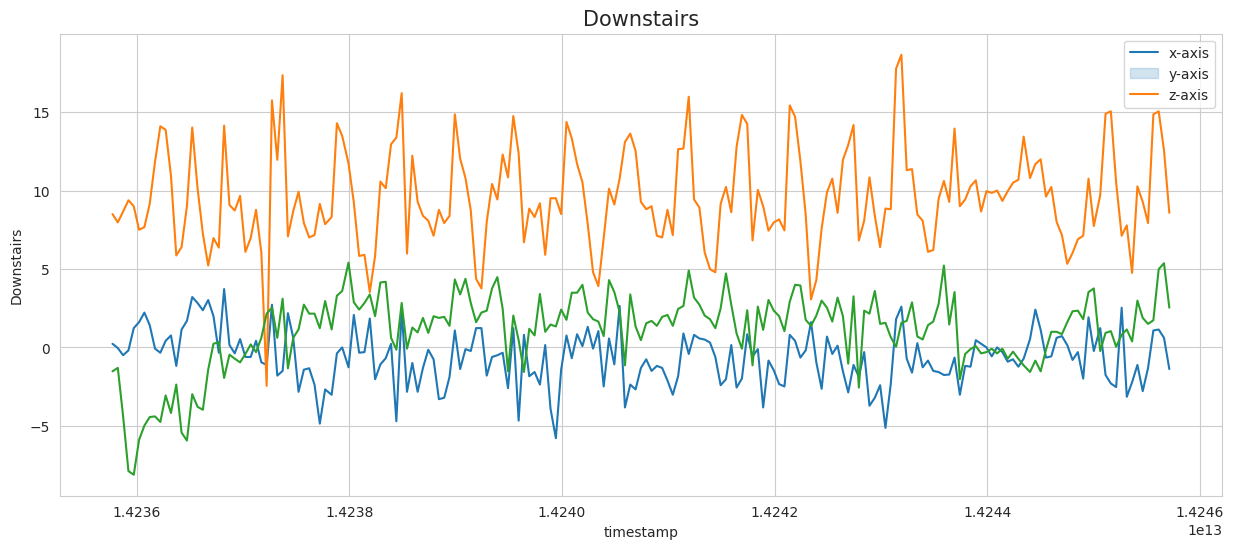

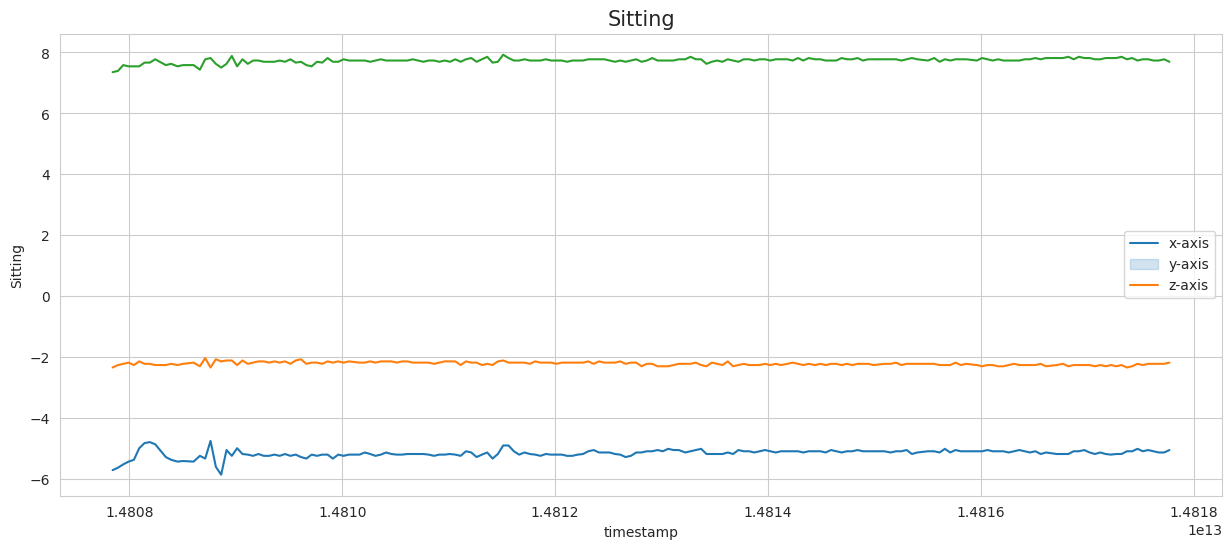

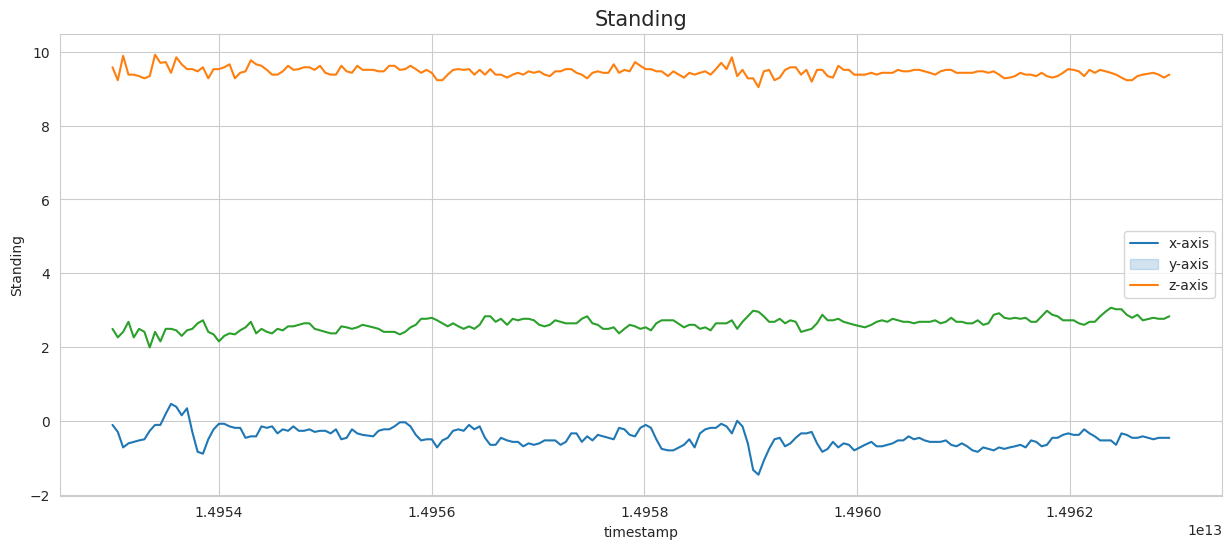

In [7]:
for i in ['Walking', 'Jogging', 'Upstairs', 'Downstairs', 'Sitting', 'Standing']:
  data_36 = df[(df['user'] == 36) & (df['activity'] == i)][:200]
  plt.figure(figsize = (15, 6))
  sns.lineplot(y = 'x-axis', x = 'timestamp', data = data_36)
  sns.lineplot(y = 'y-axis', x = 'timestamp', data = data_36)
  sns.lineplot(y = 'z-axis', x = 'timestamp', data = data_36)
  plt.legend(['x-axis', 'y-axis', 'z-axis'])
  plt.ylabel(i)
  plt.title(i, fontsize = 15)
  plt.show()

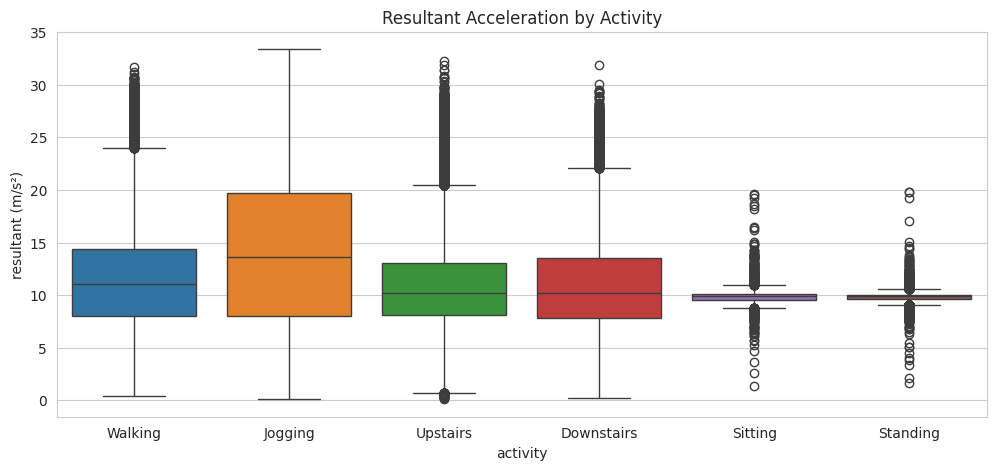

In [8]:
# Resultant acceleration per activity
df['resultant'] = (df['x-axis']**2 + df['y-axis']**2 + df['z-axis']**2) ** 0.5

plt.figure(figsize=(12, 5))
sns.boxplot(x='activity', y='resultant', data=df, palette='tab10', hue='activity', legend=False)
plt.title('Resultant Acceleration by Activity')
plt.ylabel('resultant (m/s²)')
plt.show()


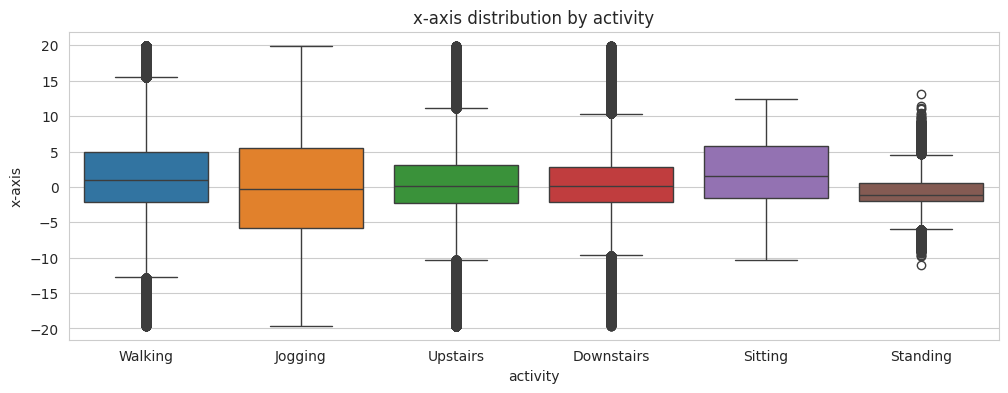

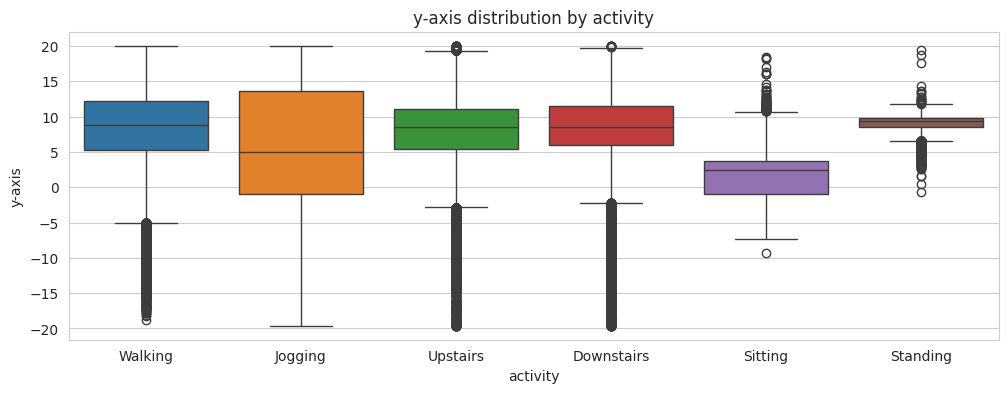

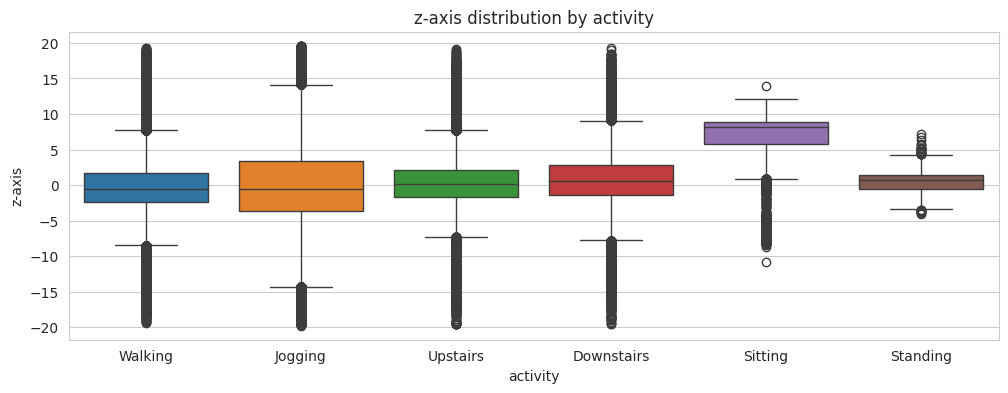

In [9]:
# Box plots of x/y/z per activity
for axis in ['x-axis', 'y-axis', 'z-axis']:
    plt.figure(figsize=(12, 4))
    sns.boxplot(x='activity', y=axis, data=df, palette='tab10', hue='activity', legend=False)
    plt.title(f'{axis} distribution by activity')
    plt.ylabel(axis)
    plt.show()


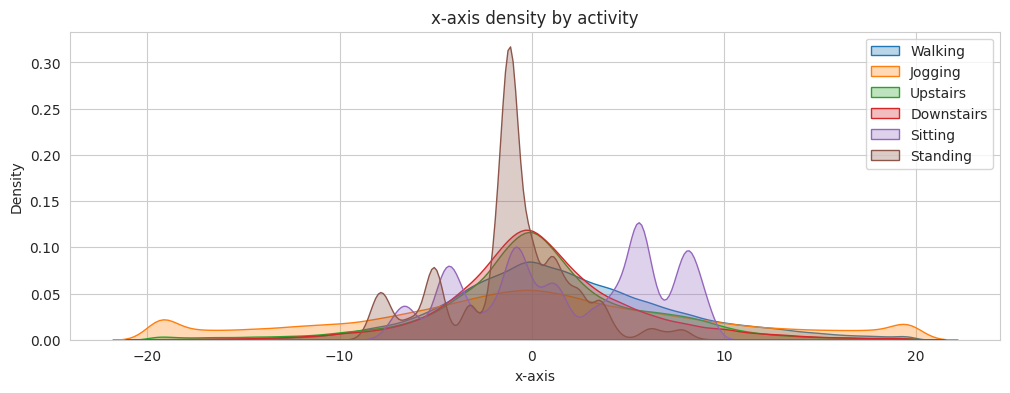

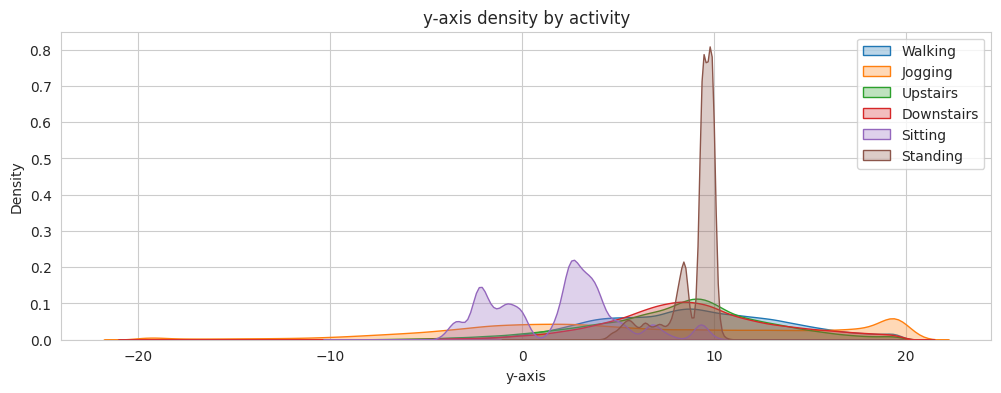

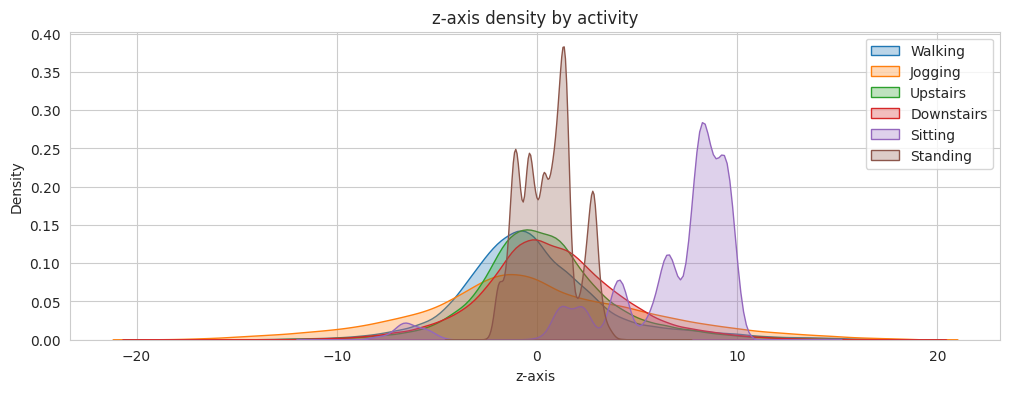

In [10]:
# KDE density plots per axis
for axis in ['x-axis', 'y-axis', 'z-axis']:
    plt.figure(figsize=(12, 4))
    for act in df['activity'].unique():
        sns.kdeplot(df[df['activity'] == act][axis], label=act, fill=True, alpha=0.3)
    plt.title(f'{axis} density by activity')
    plt.xlabel(axis)
    plt.legend()
    plt.show()


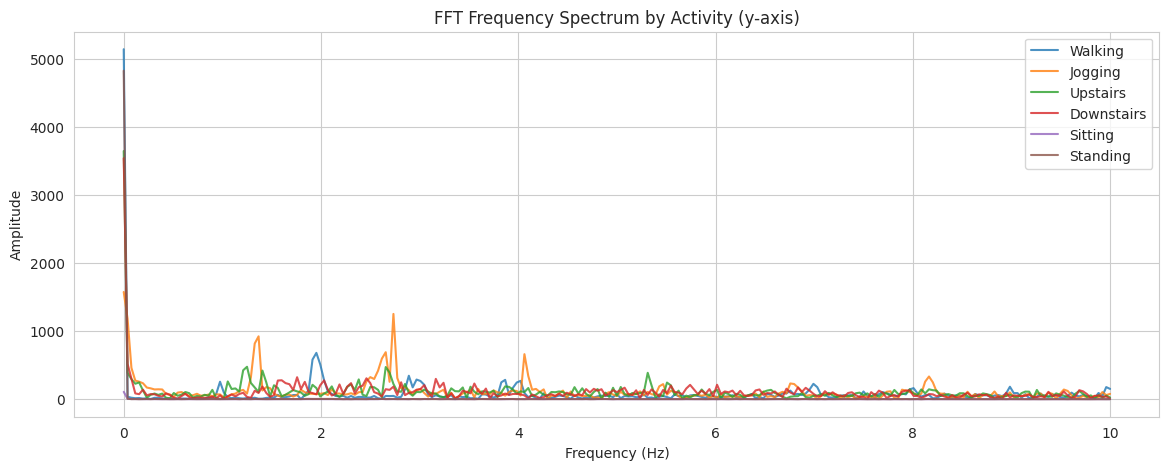

In [11]:
# FFT frequency spectrum per activity (y-axis, first 512 samples per activity)
import numpy as np

SAMPLE_RATE = 20  # Hz
N = 512
freqs = np.fft.rfftfreq(N, d=1 / SAMPLE_RATE)

plt.figure(figsize=(14, 5))
for act in df['activity'].unique():
    sig = df[df['activity'] == act]['y-axis'].values[:N]
    power = np.abs(np.fft.rfft(sig))
    plt.plot(freqs, power, label=act, alpha=0.8)

plt.title('FFT Frequency Spectrum by Activity (y-axis)')
plt.xlabel('Frequency (Hz)')
plt.ylabel('Amplitude')
plt.legend()
plt.show()


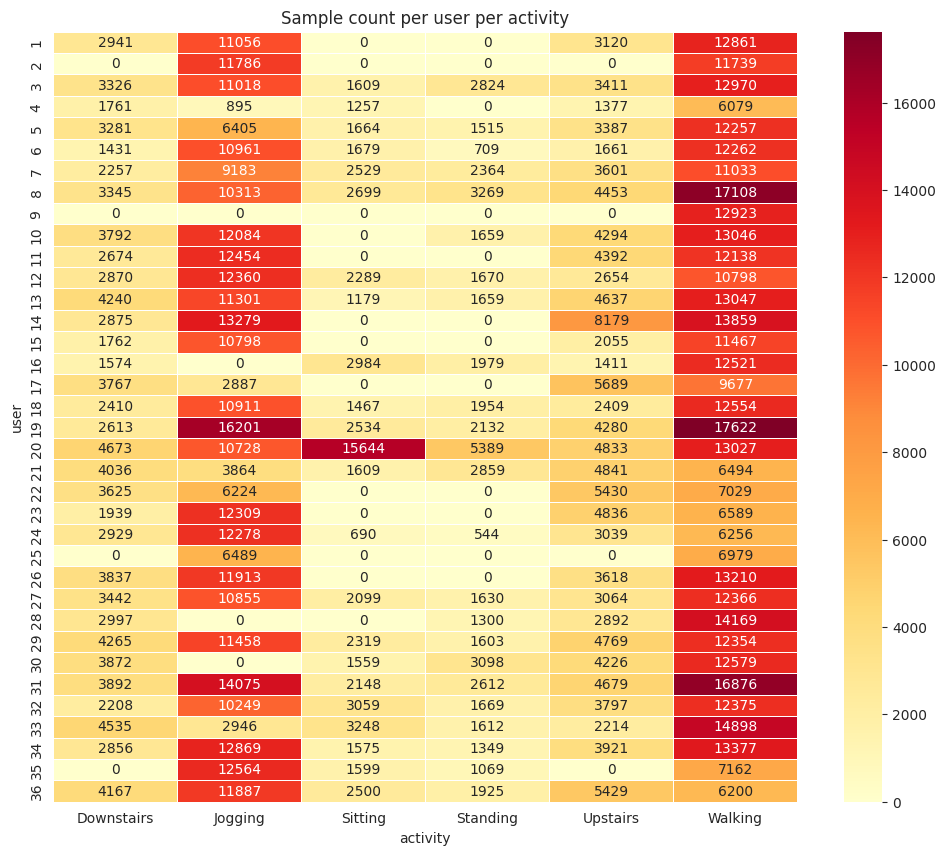

In [12]:
# Samples per user per activity heatmap
pivot = df.groupby(['user', 'activity']).size().unstack(fill_value=0)

plt.figure(figsize=(12, 10))
sns.heatmap(pivot, cmap='YlOrRd', annot=True, fmt='d', linewidths=0.5)
plt.title('Sample count per user per activity')
plt.ylabel('user')
plt.xlabel('activity')
plt.show()


## Random-Stratified Split Baseline Summary
These cells load the exact `T=100`, seed-42 random-stratified split.

In [13]:
from pathlib import Path
import json
import pandas as pd

REPO_ROOT = Path.cwd()
if not (REPO_ROOT / "src").exists() and (REPO_ROOT.parent / "src").exists():
    REPO_ROOT = REPO_ROOT.parent

split_card_path = REPO_ROOT / "data" / "processed" / "datacard_T100_Prandom_stratified.json"
with split_card_path.open("r", encoding="utf-8") as f:
    split_card = json.load(f)

classes = split_card["classes"]
split_counts = (
    pd.DataFrame(split_card["counts"])
    .T.loc[classes, ["train", "val", "test"]]
    .rename_axis("Class")
)
split_counts["total"] = split_counts.sum(axis=1)
split_counts.loc["Total"] = split_counts.sum(axis=0)
display(split_counts)

windows_final = split_card["windowing"]["windows_final"]
split_summary = pd.DataFrame([
    {
        "protocol": "random_stratified",
        "window_size": split_card["windowing"]["window_size"],
        "step": split_card["windowing"]["step"],
        "candidate_windows": split_card["windowing"]["candidate_windows"],
        "dropped_cross_boundary": split_card["windowing"]["dropped_cross_boundary"],
        "windows_final": windows_final,
        "train_size": split_card["split"]["train_size"],
        "val_size": split_card["split"]["val_size"],
        "test_size": split_card["split"]["test_size"],
        "train_pct": round(100.0 * split_card["split"]["train_size"] / windows_final, 1),
        "val_pct": round(100.0 * split_card["split"]["val_size"] / windows_final, 1),
        "test_pct": round(100.0 * split_card["split"]["test_size"] / windows_final, 1),
        "seed": 42,
        "split_hash": split_card["split"]["split_hash"],
    }
])
display(split_summary)

,train,val,test,total
Class,,,,
Walking,4423,1106,2723,8252
Jogging,3425,856,2109,6390
Upstairs,1186,297,730,2213
Downstairs,954,238,587,1779
Sitting,619,155,381,1155
Standing,493,123,304,920
Total,11100,2775,6834,20709


,protocol,window_size,step,candidate_windows,dropped_cross_boundary,windows_final,train_size,val_size,test_size,train_pct,val_pct,test_pct,seed,split_hash
0,random_stratified,100,50,21421,712,20709,11100,2775,6834,53.6,13.4,33.0,42,e8b3eefc294da8de
